In [12]:
import dataclasses
import glob
import itertools
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns

from lib.plots import faint_color, reverse_legend, set_axis
from lib.stats import fit_power_law

In [13]:
task_ids = [
    "0-no_loops",
    "1-static_loops",
    "2-static_loops_crossable",
    "3-loop_extrusion",
    "4-loop_extrusion_slow",
    "5-loop_capture",
    "6-loop_capture_transient",
]
config_count = 10

In [14]:
@dataclasses.dataclass
class TaskData:
    frame_duration: float
    msd: np.ndarray             # (replicates, lag)
    loop_coverage: np.ndarray   # (replicates)


phase_key = "production"
msd_lag_cutoff = 11


def load_task_data(task_id: str) -> TaskData:
    msd_ensemble = []
    cov_ensemble = []

    for config_id in range(config_count):
        with h5py.File(f"{task_id}/_outputs/metrics-{config_id}.h5", "r") as store:
            config_used = json.loads(store["config_used"][()])
            site_msds = store["site_msds"][:, :msd_lag_cutoff, :]   # (replicates, lag, sites)
            loop_covs = store["loop_coverages"][:, :]               # (replicates, time)
            msd_ensemble.append(site_msds)
            cov_ensemble.append(loop_covs)

    # All configs in the same task share the same sampling settings.
    # Take the last one.
    sampling_config = config_used["sampling"]
    phase_configs = {phase["name"]: phase for phase in sampling_config["phases"]}
    phase_config = {**sampling_config, **phase_configs[phase_key]}
    frame_duration = phase_config["timestep"] * phase_config["sampling_interval"]

    msd_ensemble = np.array(msd_ensemble)   # (configs, replicates, lag, sites)
    cov_ensemble = np.array(cov_ensemble)   # (configs, replicates, time)

    return TaskData(
        frame_duration=frame_duration,
        msd=msd_ensemble.mean(axis=(0, 3)),
        loop_coverage=cov_ensemble.mean(axis=(0, 2)),
    )


task_data = {
    task_id: load_task_data(task_id) for task_id in task_ids
}

In [15]:
@dataclasses.dataclass
class TaskEstimates:
    msd_mean: np.ndarray        # (lag)
    msd_stderr: np.ndarray      # (lag)
    msd_alpha: np.ndarray       # (replicates)
    msd_prefactor: np.ndarray   # (replicates)


def compute_task_estimates(data: TaskData) -> TaskEstimates:
    # Normalize lag time to the last value. This way the prefactor for the
    # power-law has the well-defined unit.
    x = np.linspace(0, 1, num=data.msd.shape[1])

    msd_alpha = []
    msd_prefactor = []
    for i in range(data.msd.shape[0]):
        y = data.msd[i, :]
        alpha, prefactor = fit_power_law(x, y)
        msd_alpha.append(alpha)
        msd_prefactor.append(prefactor)

    return TaskEstimates(
        msd_mean=np.mean(data.msd, axis=0),
        msd_stderr=np.std(data.msd, axis=0, ddof=1),
        msd_alpha=np.array(msd_alpha),
        msd_prefactor=np.array(msd_prefactor),
    )


task_estimates = {
    task_id: compute_task_estimates(data) for task_id, data in task_data.items()
}

In [20]:
@dataclasses.dataclass
class ConditionSpec:
    task_id: str
    color: any
    offset: float
    label: str


conditions = [
    ConditionSpec(task_id=task_ids[0], color="C:k", offset=0, label="No loops"),
    ConditionSpec(task_id=task_ids[5], color="C:g", offset=3, label="LC"),
    ConditionSpec(task_id=task_ids[6], color="C:b", offset=4, label="transient LC"),
    ConditionSpec(task_id=task_ids[3], color="C:r", offset=1, label="LE"),
    ConditionSpec(task_id=task_ids[4], color="C:y", offset=2, label="slow LE"),
]

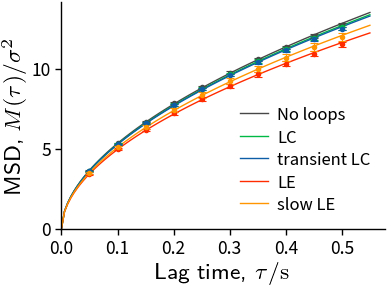

In [21]:
fig, ax = plt.subplots()

for condition in conditions:
    data = task_data[condition.task_id]
    estimates = task_estimates[condition.task_id]

    x = np.arange(len(estimates.msd_mean)) * data.frame_duration
    y = estimates.msd_mean
    y_err = estimates.msd_stderr
    ax.errorbar(
        x[1:],
        y[1:],
        y_err[1:],
        linestyle="none",
        color=condition.color,
        marker="o",
        markersize=1,
        elinewidth=0.4,
        capsize=1.3,
        capthick=0.4,
        zorder=2,
    )

    mean_alpha, mean_prefactor = fit_power_law(x, y)
    x = np.linspace(0, len(estimates.msd_mean) * data.frame_duration, num=100)
    y = x**mean_alpha * mean_prefactor
    ax.plot(x, y, color=condition.color, label=condition.label, zorder=1)

ax.legend()
ax.set_xlim(0, )
ax.set_ylim(0, )

ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Lag time, $ \tau / \mathrm{s} $", usetex=True)
ax.set_ylabel(r"MSD, $ M(\tau) / \sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

pass

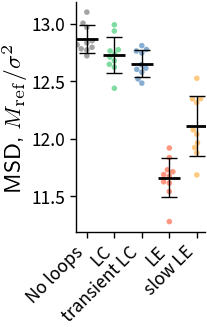

In [22]:
fig, ax = plt.subplots(figsize=(1.1, 1.7))

swarm_data = {
    condition.label: task_estimates[condition.task_id].msd_prefactor
    for condition in conditions
}

sns.swarmplot(
    swarm_data,
    palette=[faint_color(condition.color) for condition in conditions],
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions
]

ax.errorbar(
    np.arange(len(conditions)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.set_ylabel(r"MSD, $ M_\mathrm{ref}/\sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

pass

In [23]:
for cond_i, cond_j in itertools.combinations(conditions, 2):
    t_test = scipy.stats.ttest_ind(
        task_data[cond_i.task_id].msd[:, -1],
        task_data[cond_j.task_id].msd[:, -1],
    )
    print("{:25s} {:25s} -- p={:.3g}".format(cond_i.task_id, cond_j.task_id, t_test.pvalue))

0-no_loops                5-loop_capture            -- p=0.0485
0-no_loops                6-loop_capture_transient  -- p=0.00117
0-no_loops                3-loop_extrusion          -- p=5.83e-13
0-no_loops                4-loop_extrusion_slow     -- p=1.16e-07
5-loop_capture            6-loop_capture_transient  -- p=0.25
5-loop_capture            3-loop_extrusion          -- p=2.43e-11
5-loop_capture            4-loop_extrusion_slow     -- p=3.92e-06
6-loop_capture_transient  3-loop_extrusion          -- p=1.32e-11
6-loop_capture_transient  4-loop_extrusion_slow     -- p=8.98e-06
3-loop_extrusion          4-loop_extrusion_slow     -- p=0.000212


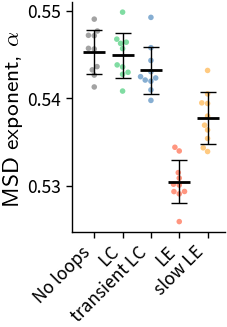

In [24]:
fig, ax = plt.subplots(figsize=(1.2, 1.7))

swarm_data = {
    condition.label: task_estimates[condition.task_id].msd_alpha
    for condition in conditions
}

sns.swarmplot(
    swarm_data,
    palette=[faint_color(condition.color) for condition in conditions],
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions
]

ax.errorbar(
    np.arange(len(conditions)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.margins(0.15, 0.05)

ax.set_ylabel(r"MSD exponent, $ \alpha $", usetex=True)

set_axis(ax, "left bottom")

pass

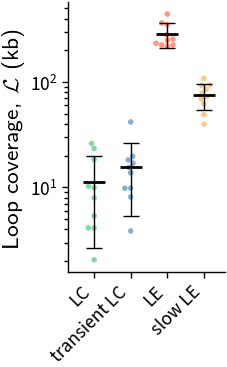

In [25]:
fig, ax = plt.subplots(figsize=(1.2, 1.9))

swarm_data = {
    condition.label: task_data[condition.task_id].loop_coverage
    for condition in conditions[1:]
}
swarm_palette = [faint_color(condition.color) for condition in conditions[1:]]

sns.swarmplot(
    swarm_data,
    palette=swarm_palette,
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions[1:]
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions[1:]
]

ax.errorbar(
    np.arange(len(swarm_data)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.margins(0.15, 0.05)
ax.set_yscale("log")

ax.set_ylabel(r"Loop coverage, $ \mathcal{L} $ (kb)", usetex=True)

set_axis(ax, "left bottom")

pass

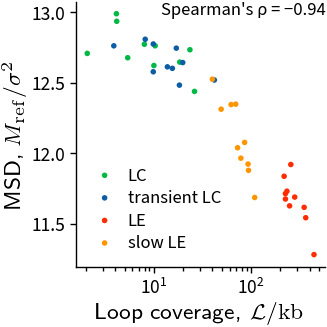

In [27]:
fig, ax = plt.subplots(figsize=(1.7, 1.7))

xs = []
ys = []

for condition in conditions[1:]:
    x = task_data[condition.task_id].loop_coverage
    y = task_estimates[condition.task_id].msd_prefactor
    ax.scatter(
        x,
        y,
        s=4,
        edgecolor="none",
        facecolor=condition.color,
        label=condition.label,
    )
    xs.extend(x)
    ys.extend(y)

spearman = scipy.stats.spearmanr(xs, ys)
s = "Spearman's ρ = " + "{:.2f}".format(spearman.statistic).replace("-", "−")
ax.text(1, 1, s, ha="right", va="top", fontsize="small", transform=ax.transAxes)

ax.set_xscale("log")

ax.legend()
ax.set_xlabel(r"Loop coverage, $ \mathcal{L}/\mathrm{kb} $", usetex=True)
ax.set_ylabel(r"MSD, $ M_\mathrm{ref}/\sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

pass